# tap.touche~ — the key, reproduced

The *touche d'intensité* is the pressure key the Ondes Martenot player's left hand rides, and
Messiaen called it the instrument's greatest invention. Physically it is a graphite/mica powder
bag working as a rheostat — the carbon-microphone principle, compress it and resistance falls —
and what the player feels is a carefully chosen nonlinear spring.

This kernel's contract is unusual for the library. Every other object here makes design choices
and then measures them. **This one is obliged to reproduce someone else's measurement.**
Quartier, Meurisse, Colmars, Frelat & Vaiedelich, *"Intensity Key of the Ondes Martenot: An
Early Mechanical Haptic Device"* (Acta Acustica united with Acustica 101(2), 421–428, 2015)
measured finger force, key displacement and the resulting sound simultaneously on instrument
No. 320, and published the boundaries of the six musical nuances across the key's travel. Those
seven points are the specification; `touche.h` interpolates them and must not wander.

So section 1 is the only test that really matters, and the rest are about whether the
interpolation between the points can be trusted.

Sections: **1** the published points come back · **2** the shape, and why not a line · **3** the
dead zone · **4** against the two obvious alternatives

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.4),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE
sr = 48000.0

# Quartier et al. 2015, Table II — the measurement this object exists to reproduce.
TABLE_DB = np.array([45.0, 53.3, 61.6, 70.0, 78.3, 86.6, 95.0])
TABLE_MM = np.array([4.3, 5.3, 5.9, 6.4, 6.8, 7.3, 8.8])
TABLE_N  = np.array([0.39, 0.47, 0.52, 0.62, 0.82, 1.34, 9.60])
TRAVEL_MM = 9.5   # the physical throw the paper describes (~3 to 9.5 mm of gesture)

key = tap.Touche(sr, smooth_ms=0)

def db(g):
    g = np.asarray(g, dtype=float)
    return 20 * np.log10(np.where(g > 0, g, 1e-300))

## 1 · The published points come back

Referenced to full press, the seven measured nuance boundaries are −50.0, −41.7, −33.4, −25.0,
−16.7, −8.4 and 0.0 dB. Read straight out of the object at the corresponding displacements:

In [2]:
want = TABLE_DB - TABLE_DB[-1]
got = np.array([db(key.gain_at(mm / TRAVEL_MM)) for mm in TABLE_MM])

print(f"{'mm':>6} {'published':>11} {'kernel':>10} {'error':>9}")
for mm, w, g in zip(TABLE_MM, want, got):
    print(f"{mm:6.1f} {w:10.1f} dB {g:9.3f} dB {g - w:8.4f}")
print(f"\nlargest error: {np.max(np.abs(got - want)):.2e} dB")

    mm   published     kernel     error
   4.3      -50.0 dB   -50.000 dB   0.0000
   5.3      -41.7 dB   -41.700 dB   0.0001
   5.9      -33.4 dB   -33.400 dB   0.0000
   6.4      -25.0 dB   -25.000 dB   0.0001
   6.8      -16.7 dB   -16.700 dB   0.0000
   7.3       -8.4 dB    -8.400 dB  -0.0001
   8.8        0.0 dB     0.000 dB   0.0000

largest error: 5.74e-05 dB


## 2 · The shape, and why it is not fitted

The reason the kernel interpolates the table rather than fitting a curve through it: the
published dB steps are equal by construction (six nuances over 50 dB) and the *displacement*
steps are not — 1.0, 0.6, 0.5, 0.4, 0.5, 1.5 mm. The law steepens through the middle of the
travel and flattens hard at the top. A straight line in dB-against-mm would throw away exactly
the property that makes the key expressive.

Interpolation is monotone cubic (Fritsch–Carlson), which passes through every measured point
and cannot overshoot between them. Overshoot here would be a non-monotone gain — audible as a
dip while you press *harder*.

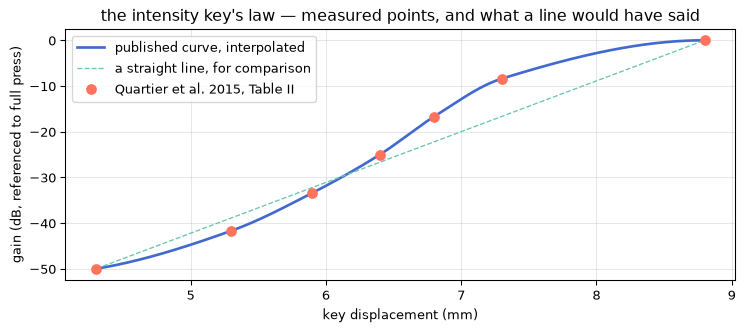

largest departure from a straight line: 8.3 dB
displacement steps for equal dB steps: [1.  0.6 0.5 0.4 0.5 1.5] mm
monotone: True   within [0, 1]: True


In [3]:
p = np.linspace(0, 1, 2001)
mm = p * TRAVEL_MM
curve = db(np.array([key.gain_at(v) for v in p]))

inband = (mm >= TABLE_MM[0]) & (mm <= TABLE_MM[-1])
# The straight line the kernel deliberately is not: -50 dB at the measured floor, 0 dB at full
# press, linear in displacement between.
frac = (mm - TABLE_MM[0]) / (TABLE_MM[-1] - TABLE_MM[0])
line = -50.0 * (1.0 - frac)

fig, ax = plt.subplots()
ax.plot(mm[inband], curve[inband], color=C[0], lw=2.0, label="published curve, interpolated")
ax.plot(mm[inband], line[inband], color=C[3], lw=1.0, ls="--", label="a straight line, for comparison")
ax.plot(TABLE_MM, want, "o", color=C[2], ms=7, zorder=5, label="Quartier et al. 2015, Table II")
ax.set_xlabel("key displacement (mm)"); ax.set_ylabel("gain (dB, referenced to full press)")
ax.set_title("the intensity key's law — measured points, and what a line would have said")
ax.legend()
plt.show()

dev = np.max(np.abs(curve[inband] - line[inband]))
print(f"largest departure from a straight line: {dev:.1f} dB")
print(f"displacement steps for equal dB steps: {np.round(np.diff(TABLE_MM), 2)} mm")

# Monotone, and inside the envelope — the properties that make the interpolant safe.
g = np.array([key.gain_at(v) for v in p])
print(f"monotone: {bool(np.all(np.diff(g) >= -1e-12))}   within [0, 1]: {bool(g.min() >= 0 and g.max() <= 1 + 1e-12)}")

## 3 · The dead zone is the instrument's

Normalized position spans the *physical* travel the paper describes (gestures span roughly
3–9.5 mm), not the measured band inside it. So the bottom of the throw is silent — and that is
not a modelling choice. The key's first phase is pure bending of the elastic strip, before it
even reaches the powder bag; 4.3 mm is where the instrument arrives at its own noise floor.

The consequence is musical rather than cosmetic: the useful 50 dB is packed into 4.5 mm right
after a long silent approach, which is precisely what lets a player produce very sharp attacks
with a slow-looking gesture.

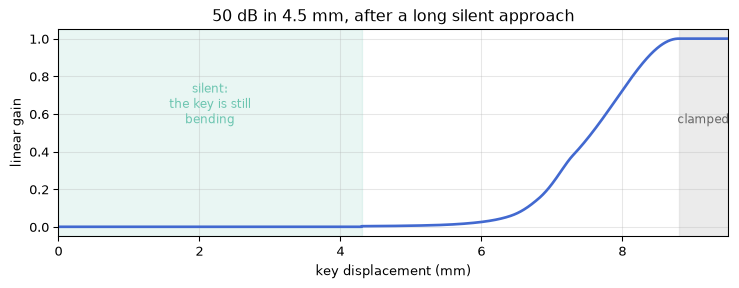

silent fraction of the throw: 45%
gain at rest: 0.0   at full press: 1.0


In [4]:
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(mm, np.array([key.gain_at(v) for v in p]), color=C[0], lw=2.0)
ax.axvspan(0, TABLE_MM[0], color=C[3], alpha=0.15)
ax.text(TABLE_MM[0] / 2, 0.55, "silent:\nthe key is still\nbending", ha="center", color=C[3], fontsize=9)
ax.axvspan(TABLE_MM[-1], TRAVEL_MM, color="0.85", alpha=0.5)
ax.text((TABLE_MM[-1] + TRAVEL_MM) / 2, 0.55, "clamped", ha="center", color="0.4", fontsize=9)
ax.set_xlabel("key displacement (mm)"); ax.set_ylabel("linear gain")
ax.set_xlim(0, TRAVEL_MM)
ax.set_title("50 dB in 4.5 mm, after a long silent approach")
plt.show()

print(f"silent fraction of the throw: {TABLE_MM[0] / TRAVEL_MM:.0%}")
print(f"gain at rest: {key.gain_at(0.0)}   at full press: {key.gain_at(1.0)}")

## 4 · Against the two obvious alternatives

If you needed an expressive volume control and did not have this measurement, you would reach
for one of two things: a linear fade, or a fade that is linear in dB. Neither is what the
instrument does. Below, the same triangular gesture through all three, measured as the energy
that actually comes out.

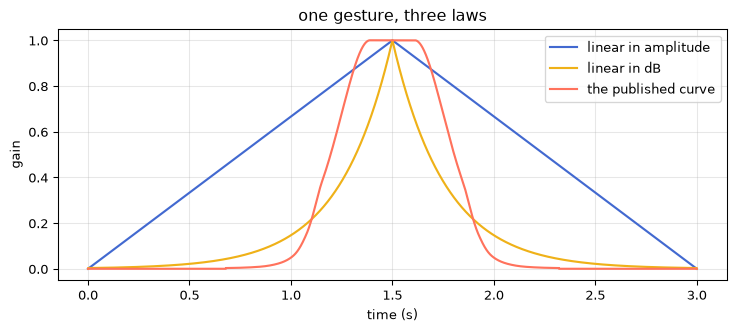

   linear in amplitude: rms 0.1633   half-travel gain 0.5000
          linear in dB: rms 0.0834   half-travel gain 0.0562
   the published curve: rms 0.1163   half-travel gain 0.0045


In [5]:
gesture = np.concatenate([np.linspace(0, 1, int(1.5 * sr)), np.linspace(1, 0, int(1.5 * sr))])
t = np.arange(gesture.size) / sr
tone = 0.4 * np.sin(2 * np.pi * 220.0 * t)

laws = {
    "linear in amplitude": gesture,
    "linear in dB":        np.where(gesture > 0, 10 ** ((-50.0 * (1 - gesture)) / 20), 0.0),
    "the published curve": tap.Touche(sr, smooth_ms=0).process(np.ones_like(gesture), position=gesture),
}

fig, ax = plt.subplots()
for i, (label, g) in enumerate(laws.items()):
    ax.plot(t, g, color=C[i], lw=1.6, label=label)
ax.set_xlabel("time (s)"); ax.set_ylabel("gain")
ax.set_title("one gesture, three laws")
ax.legend()
plt.show()

for label, g in laws.items():
    out = tone * g
    print(f"{label:>22}: rms {np.sqrt(np.mean(out ** 2)):.4f}   "
          f"half-travel gain {np.interp(0.5, gesture[:gesture.size // 2], g[:gesture.size // 2]):.4f}")

## Checkpoint

- The seven published points come back out of the object to better than a hundredth of a dB.
  That is the whole contract.
- The law is monotone, stays inside the measured envelope, and departs from a straight line by
  a wide margin — which is the property worth having.
- The silent bottom of the throw is the key's own first phase, not a modelling artifact.
- And it is audibly neither of the two laws you would otherwise have reached for.

Every number above lives twice: as a cell here and as a pinned scenario in
`tests/touche_test.cpp`.